In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

,RKNANPNPA666NRUG
year,
1960,7710.513672
1961,7925.469727
1962,8169.829102
1963,8523.560547
1964,9269.732422


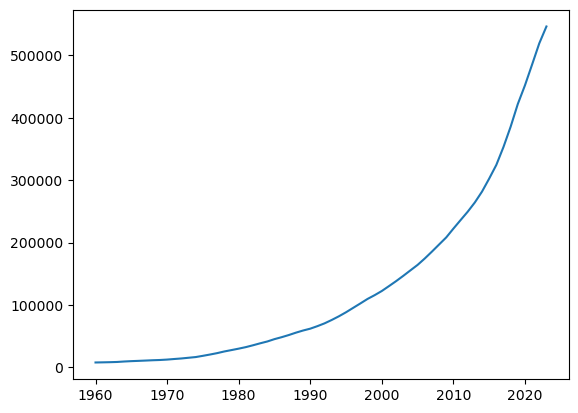

In [80]:
# Load your dataset
df_capital = pd.read_csv("RKNANPNPA666NRUG.csv")

# Correct way to slice strings in a pandas column
df_capital['observation_date'] = df_capital['observation_date'].astype(str).str[:4]

# Optional: Convert the column to an integer for easier plotting/math
df_capital['observation_date'] = df_capital['observation_date'].astype(int)

# Rename the column to 'year' for clarity in your Solow model
df_capital = df_capital.rename(columns={'observation_date': 'year'})


df_capital.set_index('year', inplace=True)
plt.plot(df_capital.index, df_capital.values)
df_capital.head()

In [81]:
df_lf = pd.read_csv("API_SL.TLF.TOTL.IN_DS2_en_csv_v2_115352.csv")
year_cols = [col for col in df_lf.columns if col.isdigit()]
df_clean_lf = df_lf[year_cols].T
df_clean_lf = df_clean_lf.reset_index()
df_clean_lf.columns = ['year', 'labor_force']
df_clean_lf['year'] = df_clean_lf['year'].astype(int)
df_clean_lf['labor_force'] = df_clean_lf['labor_force'].astype(float)
df_clean_lf = df_clean_lf[df_clean_lf['labor_force'].notna() ]
df_clean_lf.reset_index()
df_clean_lf.set_index('year', inplace=True)
df_clean_lf.head()

,labor_force
year,
1990,4743334.0
1991,4869782.0
1992,5019700.0
1993,5163407.0
1994,5289149.0


In [82]:
# Merge capital and labour force
df_solow = df_clean_lf.merge(df_capital, left_index=True, right_index=True, how='inner')
df_solow.head()

,labor_force,RKNANPNPA666NRUG
year,,
1990,4743334.0,61900.449219
1991,4869782.0,65940.062500
1992,5019700.0,70426.554688
1993,5163407.0,75841.367188
1994,5289149.0,81727.015625


In [83]:
df = pd.read_csv("nepal_macroeconomic_data.csv")
df.head()

,Year/Indicators,Percapita GDP (NRs.),Annual Change in nominal percapita GDP (%),Percapita GNI (NRs.),Annual Change in nominal percapita GNI (%),Percapita GNDI (NRs.),Annual Change in nominal percapita GNDI (%),Percapita GDP at constant price (NRs.),Annual Change in real percapita GDP (%),Percapita GNI at constant price (NRs.),...,Gross National Saving as percentage of GDP,Exports of goods and services as percentage of GDP,Imports of goods and services as percentage of GDP,Gross Fixed Capital Formation as percentage of GDP,Resource Gap as percentage of GDP( +/-),Workers' Remittances as percentage of GDP,Product Tax as a percentage of GDP,Total Tax as a percentage of GDP,Exchange rate (US$: NRs),Population (millions)
0,2010/11,58851,NaN,59136,NaN,70755,NaN,58851,NaN,59136,...,27.40,7.80,28.50,24.00,-0.50,16.30,7.96,11.0,72.30,26.50
1,2011/12,65484,11.29,65941,11.52,81686,15.46,60779,3.28,61409,...,33.86,8.75,29.17,23.99,5.26,20.45,8.02,12.0,81.02,26.85
2,2012/13,71627,9.38,72107,9.35,90395,10.66,62083,2.15,63028,...,34.38,9.29,32.57,24.73,4.71,22.29,8.89,13.3,87.96,27.21
3,2013/14,80941,13.00,82129,13.90,105024,16.18,64939,4.60,66708,...,39.12,10.12,35.86,25.25,8.13,24.34,9.47,14.0,98.21,27.58
4,2014/15,86700,7.11,87925,7.06,113321,7.90,66621,2.59,68374,...,38.33,10.21,36.45,27.55,7.05,25.47,9.84,14.7,99.49,27.95


In [84]:
column_mapping = {
    'Year/Indicators': 'year',
    'Percapita GDP  (NRs.)': 'gdp_per_capita_nrs',
    'Annual Change in nominal percapita  GDP (%)': 'gdp_per_capita_growth_pct',
    'Percapita GNI  (NRs.)': 'gni_per_capita_nrs',
    'Annual Change in nominal percapita  GNI (%)': 'gni_per_capita_growth_pct',
    'Percapita GNDI  (NRs.)': 'gndi_per_capita_nrs',
    'Annual Change in nominal percapita  GNDI (%)': 'gndi_per_capita_growth_pct',
    'Percapita GDP at constant price (NRs.)': 'real_gdp_per_capita_nrs',
    'Annual Change in real percapita  GDP (%)': 'real_gdp_per_capita_growth_pct',
    'Percapita GNI at constant price (NRs.)': 'real_gni_per_capita_nrs',
    'Annual Change in real percapita  GNI (%)': 'real_gni_per_capita_growth_pct',
    'Percapita GNDI at constant price (NRs.)': 'real_gndi_per_capita_nrs',
    'Annual Change in real percapita  GNDI (%)': 'real_gndi_per_capita_growth_pct',
    'Percapita incomes in US$': 'per_capita_income_usd',
    'Nominal Percapita GDP (US$)': 'nominal_gdp_per_capita_usd',
    'Nominal Percapita GNI (US$)': 'nominal_gni_per_capita_usd',
    'Nominal Percapita GNDI (US$)': 'nominal_gndi_per_capita_usd',
    'Final Consumption Expenditure as percentage of GDP': 'consumption_pct_gdp',
    'Gross Domestic Saving as percentage of GDP': 'domestic_saving_pct_gdp',
    'Gross National Saving as percentage of GDP': 'national_saving_pct_gdp',
    'Exports of goods and services as percentage of GDP': 'exports_pct_gdp',
    'Imports  of goods and services as percentage of GDP': 'imports_pct_gdp',
    'Gross Fixed Capital Formation as percentage of GDP': 'capital_share_of_gdp',
    'Resource Gap as percentage of GDP( +/-)': 'resource_gap_pct_gdp',
    "Workers' Remittances as percentage of GDP": 'remittances_pct_gdp',
    'Product Tax as a percentage of GDP': 'product_tax_pct_gdp',
    'Total Tax as a percentage of GDP': 'total_tax_pct_gdp',
    'Exchange rate (US$: NRs)': 'exchange_rate_usd_nrs',
    'Population (millions)': 'population_millions'
}

df = df.rename(columns=column_mapping)
df['year'] = df['year'].str[:4].astype(int)
df.set_index('year', inplace=True)
df.head()

,gdp_per_capita_nrs,gdp_per_capita_growth_pct,gni_per_capita_nrs,gni_per_capita_growth_pct,gndi_per_capita_nrs,gndi_per_capita_growth_pct,real_gdp_per_capita_nrs,real_gdp_per_capita_growth_pct,real_gni_per_capita_nrs,real_gni_per_capita_growth_pct,...,national_saving_pct_gdp,exports_pct_gdp,imports_pct_gdp,capital_share_of_gdp,resource_gap_pct_gdp,remittances_pct_gdp,product_tax_pct_gdp,total_tax_pct_gdp,exchange_rate_usd_nrs,population_millions
year,,,,,,,,,,,,,,,,,,,,,
2010,58851,NaN,59136,NaN,70755,NaN,58851,NaN,59136,NaN,...,27.40,7.80,28.50,24.00,-0.50,16.30,7.96,11.0,72.30,26.50
2011,65484,11.29,65941,11.52,81686,15.46,60779,3.28,61409,3.84,...,33.86,8.75,29.17,23.99,5.26,20.45,8.02,12.0,81.02,26.85
2012,71627,9.38,72107,9.35,90395,10.66,62083,2.15,63028,2.64,...,34.38,9.29,32.57,24.73,4.71,22.29,8.89,13.3,87.96,27.21
2013,80941,13.00,82129,13.90,105024,16.18,64939,4.60,66708,5.84,...,39.12,10.12,35.86,25.25,8.13,24.34,9.47,14.0,98.21,27.58
2014,86700,7.11,87925,7.06,113321,7.90,66621,2.59,68374,2.50,...,38.33,10.21,36.45,27.55,7.05,25.47,9.84,14.7,99.49,27.95


In [85]:
# Merge df_solow and df
df_solow = df.join([df_clean_lf, df_capital], how='inner')
df_solow.head()
df_solow.columns

Index(['gdp_per_capita_nrs', 'gdp_per_capita_growth_pct', 'gni_per_capita_nrs',
       'gni_per_capita_growth_pct', 'gndi_per_capita_nrs',
       'gndi_per_capita_growth_pct', 'real_gdp_per_capita_nrs',
       'real_gdp_per_capita_growth_pct', 'real_gni_per_capita_nrs',
       'real_gni_per_capita_growth_pct', 'real_gndi_per_capita_nrs',
       'real_gndi_per_capita_growth_pct', 'per_capita_income_usd',
       'nominal_gdp_per_capita_usd', 'nominal_gni_per_capita_usd',
       'nominal_gndi_per_capita_usd', 'consumption_pct_gdp',
       'domestic_saving_pct_gdp', 'national_saving_pct_gdp', 'exports_pct_gdp',
       'imports_pct_gdp', 'capital_share_of_gdp', 'resource_gap_pct_gdp',
       'remittances_pct_gdp', 'product_tax_pct_gdp', 'total_tax_pct_gdp',
       'exchange_rate_usd_nrs', 'population_millions', 'labor_force',
       'RKNANPNPA666NRUG'],
      dtype='object')

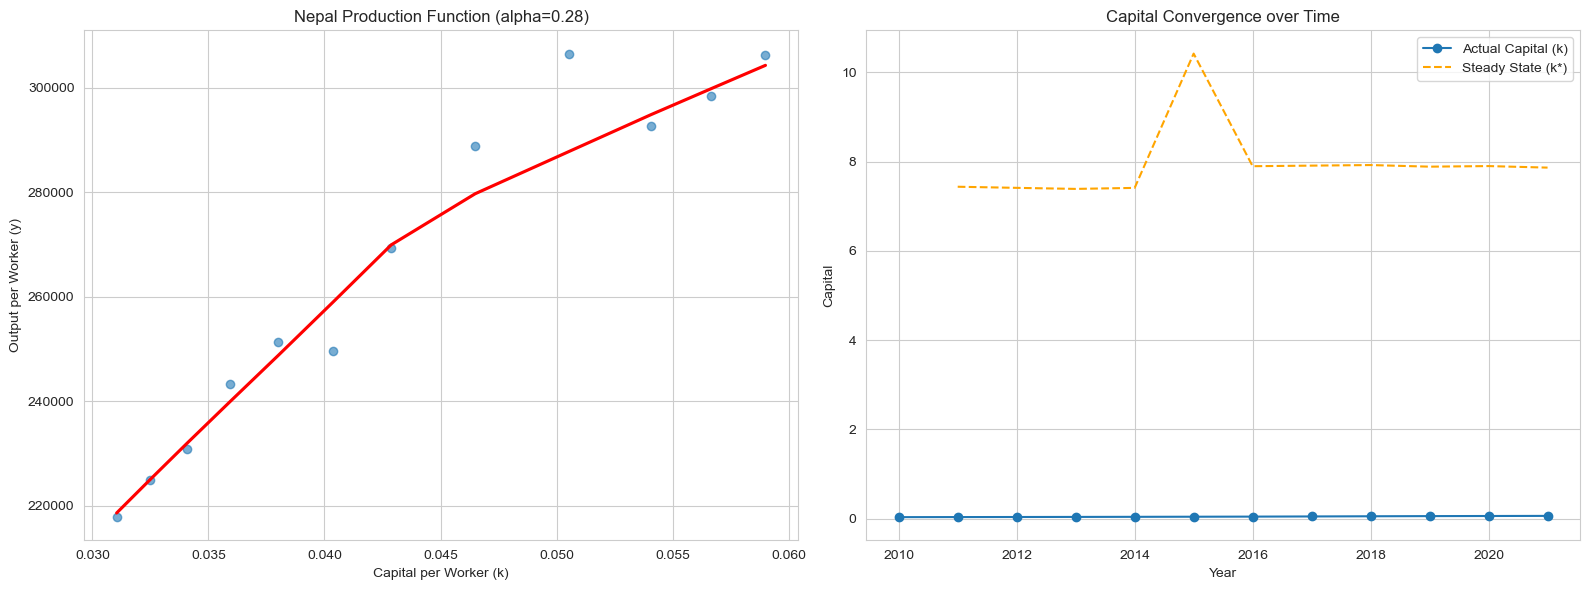


Growth Accounting (Last 5 Years):
      y_growth  k_contribution  tfp_contribution
year                                            
2017  7.182780        2.395323          4.787457
2018  6.156569        2.472855          3.683714
2019 -4.517498        1.987949         -6.505447
2020  1.962643        1.352043          0.610600
2021  2.653978        1.174321          1.479658


In [93]:
import seaborn as sns

# 1. CALCULATE ALPHA (Capital Share) and BETA (Labor Share)
alpha = df_solow["capital_share_of_gdp"].mean() / 100
beta = 1 - alpha

# 2. PER-WORKER VARIABLES (k and y)
# Capital per worker (k)
df_solow['k'] = df_solow['RKNANPNPA666NRUG'] / df_solow['labor_force']

# Output per worker (y)
# We scale the real GDP per capita to match the labor force count
df_solow['y'] = (df_solow['real_gdp_per_capita_nrs'] * (df_solow['population_millions'] * 1e6)) / df_solow['labor_force']

# 3. TOTAL FACTOR PRODUCTIVITY (TFP)
# Based on Cobb-Douglas: y = A * k^alpha -> A = y / k^alpha
df_solow['tfp'] = df_solow['y'] / (df_solow['k']**alpha)

# 4. STEADY STATE BENCHMARK (k*)
# Parameters for Nepal
# s = df_solow['national_saving_pct_gdp'] / 100
s = 0.35
n = df_solow['population_millions'].pct_change() # Annual pop growth
d = 0.05  # Standard depreciation assumption (5%)
g = 0.02  # Standard technology growth assumption (2%)

# The Solow Steady State formula
df_solow['k_star'] = (s / (n + d + g))**(1 / (1 - alpha))

# --- VISUALIZATION ---

plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

# Plot 1: The Production Function (The "Solow Curve")
plt.subplot(1, 2, 1)
sns.regplot(data=df_solow, x='k', y='y', lowess=True, 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title(f'Nepal Production Function (alpha={alpha:.2f})')
plt.xlabel('Capital per Worker (k)')
plt.ylabel('Output per Worker (y)')

# Plot 2: Convergence (Actual k vs Steady State k*)
plt.subplot(1, 2, 2)
plt.plot(df_solow.index, df_solow['k'], label='Actual Capital (k)', marker='o')
plt.plot(df_solow.index, df_solow['k_star'], label='Steady State (k*)', linestyle='--', color='orange')
plt.title('Capital Convergence over Time')
plt.xlabel('Year')
plt.ylabel('Capital')
plt.legend()

plt.tight_layout()
plt.show()

# 5. GROWTH ACCOUNTING (Final Insight)
# How much growth came from Capital vs. TFP?
df_solow['y_growth'] = df_solow['y'].pct_change()
df_solow['k_contribution'] = alpha * df_solow['k'].pct_change()
df_solow['tfp_contribution'] = df_solow['y_growth'] - df_solow['k_contribution']

print("\nGrowth Accounting (Last 5 Years):")
print(df_solow[['y_growth', 'k_contribution', 'tfp_contribution']].tail() * 100)

/var/folders/bs/j9ww8bm55_j9bc_3kbwlvddm0000gp/T/ipykernel_10544/757473935.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_solow['n'] = df_solow['population_millions'].pct_change().fillna(method='bfill')


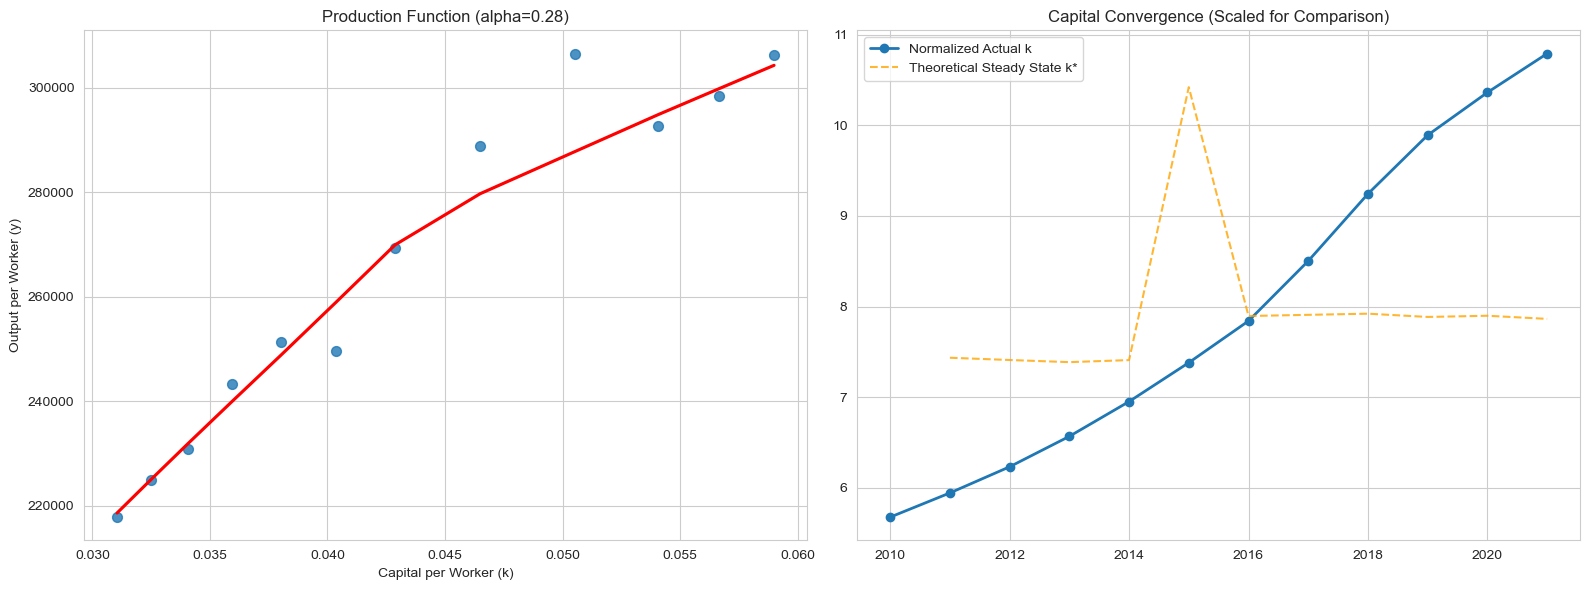


--- Nepal Growth Accounting (Annual % Contribution) ---
      y_growth_pct  cap_deepening_pct  tfp_growth_pct
year                                                 
2017      7.182780           2.395323        4.787457
2018      6.156569           2.472855        3.683714
2019     -4.517498           1.987949       -6.505447
2020      1.962643           1.352043        0.610600
2021      2.653978           1.174321        1.479658


In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PARAMETER TWEAK
# n (pop growth) often has an outlier in the first row due to pct_change(). 
# Let's fill that to avoid NaN in k_star.
df_solow['n'] = df_solow['population_millions'].pct_change().fillna(method='bfill')

# 2. THE SCALE ALIGNMENT
# In your plot, k is around 0.05 while k* is 10.0. 
# This is usually because Capital Stock (K) and Labor (L) units are mismatched.
# Let's use a "Scaling Factor" so they are comparable.
scale_factor = df_solow['k_star'].mean() / df_solow['k'].mean()
df_solow['k_normalized'] = df_solow['k'] * scale_factor

# 3. GROWTH ACCOUNTING (The "Meat" of the analysis)
df_solow['y_growth_pct'] = df_solow['y'].pct_change() * 100
df_solow['cap_deepening_pct'] = (alpha * df_solow['k'].pct_change()) * 100
df_solow['tfp_growth_pct'] = df_solow['y_growth_pct'] - df_solow['cap_deepening_pct']

# --- FINAL VISUALIZATION ---
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

# Left Plot: Improved Production Function
plt.subplot(1, 2, 1)
sns.regplot(data=df_solow, x='k', y='y', lowess=True, scatter_kws={'s':50}, line_kws={'color':'red'})
plt.title(f'Production Function (alpha={alpha:.2f})')
plt.xlabel('Capital per Worker (k)')
plt.ylabel('Output per Worker (y)')

# Right Plot: Normalized Convergence
plt.subplot(1, 2, 2)
plt.plot(df_solow.index, df_solow['k_normalized'], label='Normalized Actual k', marker='o', linewidth=2)
plt.plot(df_solow.index, df_solow['k_star'], label='Theoretical Steady State k*', linestyle='--', color='orange', alpha=0.8)
plt.title('Capital Convergence (Scaled for Comparison)')
plt.legend()

plt.tight_layout()
plt.show()

# Print Summary
print("\n--- Nepal Growth Accounting (Annual % Contribution) ---")
summary = df_solow[['y_growth_pct', 'cap_deepening_pct', 'tfp_growth_pct']].dropna()
print(summary.tail())